# Real-study inference and Grad-CAM
Load the selected checkpoint independently of training. This notebook uses the packaged MRNet validation study 1130. All three uploaded sequences must belong to the same study. Input support is MRNet-style NumPy stacks or a ZIP containing named planes; V1 does not directly parse DICOM/NIfTI.


In [1]:
from pathlib import Path
import sys, json
candidates = [Path.cwd(), Path.cwd().parent]
ROOT = next((p for p in candidates if (p / "config.yaml").exists() and (p / "src").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook from KneeAssist-AI or its notebooks folder.")
sys.path.insert(0, str(ROOT))
from src.utils import config
cfg = config(ROOT / "config.yaml")
print("Project:", ROOT)
print("Python:", sys.executable)


Project: C:\Users\HP\Desktop\KneeAssist-AI
Python: C:\Users\HP\Desktop\KneeAssist-AI\.venv\Scripts\python.exe


In [2]:
from src.data.preprocessing import load_uploads
from src.inference.predictor import Predictor, text_summary
study_path = ROOT / "sample_cases/mrnet_1130.zip"
volumes = load_uploads([(study_path.name, study_path.read_bytes())], cfg["preprocessing"])
predictor = Predictor(cfg=cfg)
result = predictor.predict(volumes, "NOTEBOOK-MRNET-1130")
print(text_summary(result))


KneeAssist AI V1
Case: NOTEBOOK-MRNET-1130
Model: efficientnet_b0

Checkpoint SHA256: b60293f6c7130fd646c81b6d758584faf3e17b2689503b5278ad711156d546da
Training stage: frozen_warmup

General Abnormality: 58.0% — Below model threshold (threshold 0.69)
ACL Tear: 8.6% — Below model threshold (threshold 0.25)
Meniscal Tear: 2.8% — Below model threshold (threshold 0.48)

Score separation: Moderate
Model confidence: Not clinically established
Score separation is distance from decision thresholds, not a probability that the model is correct.
Probabilities were calibrated on a small reserved MRNet development subset; clinical and external calibration are not established.

Decision-support output. Clinical review required. Below-threshold results do not rule out injury.
Heatmaps show model attention, not confirmed lesions.


In [3]:
import pandas as pd
from IPython.display import display
display(pd.DataFrame(result["findings"])[["finding", "probability", "threshold", "status"]])
print("Available planes:", result["available_planes"])
print("Sampled slices:", result["sampled_slices"])


,finding,probability,threshold,status
0,General Abnormality,0.580439,0.694368,Below model threshold
1,ACL Tear,0.086201,0.246083,Below model threshold
2,Meniscal Tear,0.027940,0.480775,Below model threshold


Available planes: ['axial', 'coronal', 'sagittal']
Sampled slices: {'axial': [0, 2, 4, 7, 9, 11, 13, 15, 17, 20, 22, 24], 'coronal': [0, 2, 4, 7, 9, 11, 13, 15, 17, 20, 22, 24], 'sagittal': [0, 2, 5, 7, 9, 12, 14, 17, 19, 21, 24, 26]}


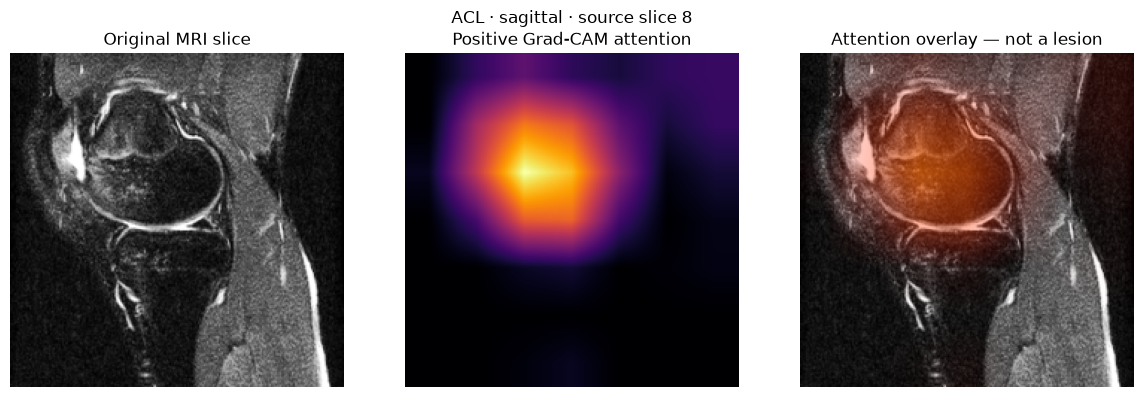

Positive model attention for this finding. It is not a confirmed lesion or segmentation.


In [4]:
import matplotlib.pyplot as plt
# Change TARGET and PLANE to explore other model decisions.
TARGET = "acl"
PLANE = "sagittal"
attention = predictor.explain(volumes, TARGET, PLANE)
index = attention["suggested_slice"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(attention["original"][index], cmap="gray"); axes[0].set_title("Original MRI slice")
axes[1].imshow(attention["heatmaps"][index], cmap="inferno", vmin=0, vmax=1); axes[1].set_title("Positive Grad-CAM attention")
axes[2].imshow(attention["overlay"][index]); axes[2].set_title("Attention overlay — not a lesion")
for axis in axes: axis.axis("off")
fig.suptitle(f"{TARGET.upper()} · {PLANE} · source slice {attention['indices'][index]+1}")
fig.tight_layout()
display(fig); plt.close(fig)
print(attention["note"])
if not attention["has_positive_attention"]: print("No positive attention signal for this finding/plane.")


In [5]:
from src.utils import save_json
save_json(ROOT / "results/notebook_inference.json", result)
print("Saved a structured research inference example to results/notebook_inference.json")
# Missing-plane handling is supported, with an explicit warning.
incomplete = predictor.predict({"sagittal": volumes["sagittal"]}, "INCOMPLETE-RESEARCH-EXAMPLE")
print(incomplete["incomplete_study_warning"])


Saved a structured research inference example to results/notebook_inference.json
Missing sequence performance has not been separately validated.


## Interpretation
Model probabilities are uncalibrated. Score separation is a heuristic distance from thresholds, not clinical confidence. A below-threshold result does not rule out injury. Grad-CAM shows positive model attention and cannot confirm a lesion. Clinical review is required.
